# Ejercicios clase 7 — Métodos de clustering sobre *Iris*
**Aprendizaje de Máquina — CEIA — FIUBA**

Resolvemos los tres ejercicios de la consigna usando el dataset [Iris Species](https://archive.ics.uci.edu/dataset/53/iris): 150 flores de tres especies (*setosa*, *versicolor*, *virginica*) con cuatro medidas (largo/ancho de sépalo y pétalo).

Aunque conocemos la clase real de cada flor, la usamos sólo para **evaluar** los métodos de agrupamiento (no supervisados). El procedimiento sigue la teoría de `cluster.ipynb`: método del codo + silueta para K-means, fuerza de predicción para GMM, y dendrograma para clustering jerárquico.

> Las celdas de **interpretación** quedan como _placeholder_ para completar.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.cluster.hierarchy import linkage, dendrogram, fcluster
from scipy.stats import mode

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.mixture import GaussianMixture
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (silhouette_score, accuracy_score,
                             adjusted_rand_score, confusion_matrix,
                             classification_report)

# Módulo de fuerza de predicción provisto en la teoría (Tibshirani & Walther)
from pred_strength import prediction_strength_cross_validation

sns.set()
RANDOM_STATE = 42

## 1. Carga del dataset y análisis exploratorio

El CSV viene **sin encabezado**: las primeras cuatro columnas son las medidas y la quinta es la especie. Le asignamos nombres explícitos.

In [2]:
cols = ['sepal_length', 'sepal_width', 'petal_length', 'petal_width', 'species']
iris = pd.read_csv('datasets/iris.csv', header=None, names=cols)
iris.head()

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,Iris-setosa
1,4.9,3.0,1.4,0.2,Iris-setosa
2,4.7,3.2,1.3,0.2,Iris-setosa
3,4.6,3.1,1.5,0.2,Iris-setosa
4,5.0,3.6,1.4,0.2,Iris-setosa


In [3]:
iris.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   sepal_length  150 non-null    float64
 1   sepal_width   150 non-null    float64
 2   petal_length  150 non-null    float64
 3   petal_width   150 non-null    float64
 4   species       150 non-null    object 
dtypes: float64(4), object(1)
memory usage: 6.0+ KB


In [4]:
iris.describe()

,sepal_length,sepal_width,petal_length,petal_width
count,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.054000,3.758667,1.198667
std,0.828066,0.433594,1.764420,0.763161
min,4.300000,2.000000,1.000000,0.100000
25%,5.100000,2.800000,1.600000,0.300000
50%,5.800000,3.000000,4.350000,1.300000
75%,6.400000,3.300000,5.100000,1.800000
max,7.900000,4.400000,6.900000,2.500000


In [5]:
iris['species'].value_counts()

species
Iris-setosa        50
Iris-versicolor    50
Iris-virginica     50
Name: count, dtype: int64

Visualizamos cómo se separan las especies por pares de variables (`pairplot`).

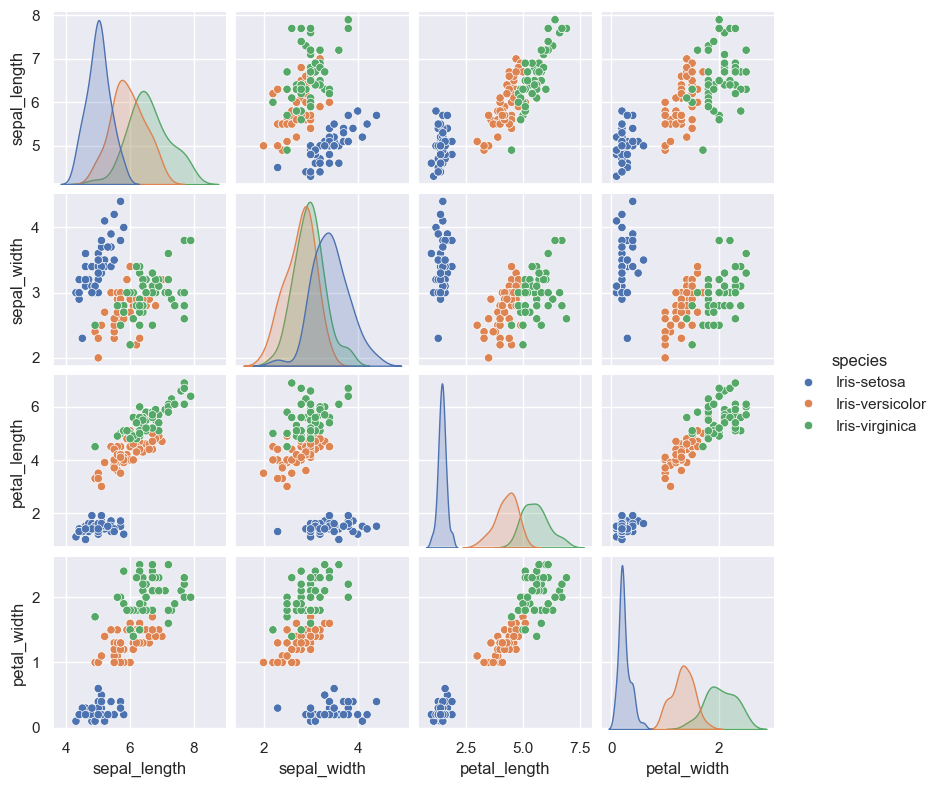

In [6]:
sns.pairplot(iris, hue='species', height=2.0)
plt.show()

### Preparación de los datos

- `X`: las cuatro features numéricas.
- `y_true`: la especie codificada a entero (sólo para **evaluar**).
- Estandarizamos con `StandardScaler`: los métodos de clustering usan distancias, conviene que todas las variables tengan magnitud comparable.

In [7]:
feature_cols = ['sepal_length', 'sepal_width', 'petal_length', 'petal_width']
X = iris[feature_cols].values

species_names = sorted(iris['species'].unique())
code_map = {name: i for i, name in enumerate(species_names)}
y_true = iris['species'].map(code_map).values

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled.shape, species_names

((150, 4), ['Iris-setosa', 'Iris-versicolor', 'Iris-virginica'])

### Helper: voto de mayoría

Como el clustering no conoce las etiquetas, asignamos a **cada cluster la especie mayoritaria** entre sus miembros del conjunto de entrenamiento. Luego una nueva observación se clasifica con la especie del cluster que le toca. Estas dos funciones se reutilizan en los tres ejercicios.

In [8]:
def map_clusters_to_labels(cluster_ids, y_train):
    """Para cada cluster, especie mayoritaria en el train. Devuelve dict cluster->clase."""
    mapping = {}
    for c in np.unique(cluster_ids):
        miembros = y_train[cluster_ids == c]
        mapping[c] = mode(miembros, keepdims=False).mode
    return mapping


def predict_class(cluster_ids, mapping):
    """Traduce ids de cluster a clases usando el mapeo del voto de mayoría."""
    return np.array([mapping[c] for c in cluster_ids])


def assign_by_nearest_centroid(X_train, cluster_ids, X_query):
    """Asigna cada fila de X_query al cluster cuyo centroide (calculado en el
    train) está más cerca. Útil para modelos sin metodo predict (jerárquico)."""
    clusters = np.unique(cluster_ids)
    centroids = np.array([X_train[cluster_ids == c].mean(axis=0) for c in clusters])
    dists = np.linalg.norm(X_query[:, None, :] - centroids[None, :, :], axis=2)
    return clusters[np.argmin(dists, axis=1)]

### Split 80/20 común

Separamos un 20% de test **una sola vez** y lo reutilizamos en los tres ejercicios, para que la comparación final sea justa (mismo conjunto de evaluación). Estratificamos por especie.

In [9]:
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y_true, test_size=0.2, random_state=RANDOM_STATE, stratify=y_true
)
X_train.shape, X_test.shape

((120, 4), (30, 4))

## Ejercicio 1 — K-means

### 1.1 Número de clusters: método del codo

Ajustamos K-means para varios `k` y graficamos la suma de cuadrados intracluster (WCSS = `inertia_`). El **codo** marca el `k` a partir del cual agregar clusters ya no reduce mucho el WCSS. Lo complementamos con el **índice de silueta** (mayor es mejor).

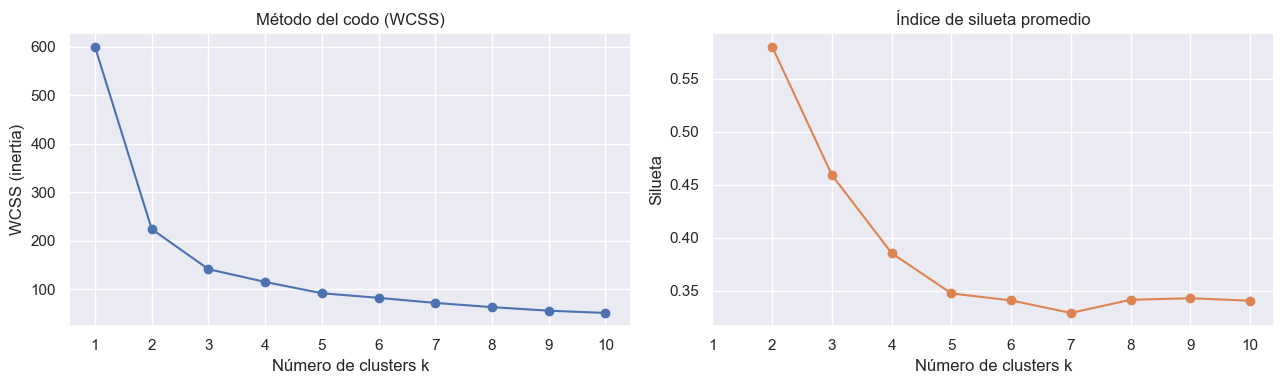

In [10]:
wcss = []
sil = []
ks = range(1, 11)
for k in ks:
    km = KMeans(n_clusters=k, init='k-means++', n_init=10,
                max_iter=300, random_state=RANDOM_STATE)
    labels = km.fit_predict(X_scaled)
    wcss.append(km.inertia_)
    sil.append(silhouette_score(X_scaled, labels) if k > 1 else np.nan)

fig, ax = plt.subplots(1, 2, figsize=(13, 4))
ax[0].plot(list(ks), wcss, marker='o')
ax[0].set_title('Método del codo (WCSS)')
ax[0].set_xlabel('Número de clusters k'); ax[0].set_ylabel('WCSS (inertia)')
ax[0].set_xticks(list(ks))
ax[1].plot(list(ks), sil, marker='o', color='C1')
ax[1].set_title('Índice de silueta promedio')
ax[1].set_xlabel('Número de clusters k'); ax[1].set_ylabel('Silueta')
ax[1].set_xticks(list(ks))
plt.tight_layout(); plt.show()

**1.1 — ¿Cuántos clusters elegir? ¿Coincide con el nº de especies (3)? ¿Hay correlación entre clusters y especies?**

En base al metodo del codo, se podria usar 3, pero si uno mira el indice de la silueta 7 parece ser un mejor valor de clusters. Seria esperable que 3 sea el numero que mejor indice de, por lo que no hay correlacion entre cluster y especies

### 1.2 – 1.3 Modelo con el k óptimo y voto de mayoría

Tomamos `k = 3` (número de especies) y entrenamos K-means sobre el 80%. Con el voto de mayoría asignamos cada cluster a una especie.

In [11]:
K_OPT = 3
kmeans = KMeans(n_clusters=K_OPT, init='k-means++', n_init=10,
                max_iter=300, random_state=RANDOM_STATE)
clusters_train_km = kmeans.fit_predict(X_train)

map_km = map_clusters_to_labels(clusters_train_km, y_train)
print('Mapeo cluster -> especie:',
      {int(c): species_names[lbl] for c, lbl in map_km.items()})

# Composición de cada cluster en el train
pd.crosstab(clusters_train_km, pd.Series(y_train, name='especie_real'))

Mapeo cluster -> especie: {0: 'Iris-virginica', 1: 'Iris-setosa', 2: 'Iris-versicolor'}


especie_real,0,1,2
row_0,,,
0,0,5,26
1,40,0,0
2,0,35,14


### 1.4 Clasificación del 20% reservado

Predecimos el cluster de cada flor de test, lo traducimos a especie y evaluamos con **accuracy** y **Adjusted Rand Index** (ARI, mide acuerdo de agrupamiento sin depender de cómo se numeren los clusters).

Accuracy (test): 0.8000
ARI (test):      0.5489

                 precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00        10
Iris-versicolor       0.70      0.70      0.70        10
 Iris-virginica       0.70      0.70      0.70        10

       accuracy                           0.80        30
      macro avg       0.80      0.80      0.80        30
   weighted avg       0.80      0.80      0.80        30



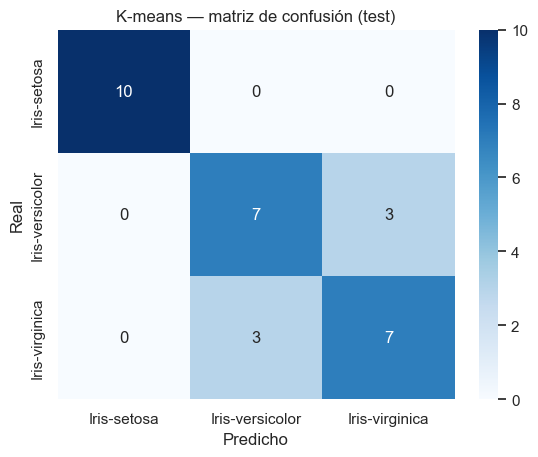

In [12]:
clusters_test_km = kmeans.predict(X_test)
y_pred_km = predict_class(clusters_test_km, map_km)

acc_km = accuracy_score(y_test, y_pred_km)
ari_km = adjusted_rand_score(y_test, clusters_test_km)
print(f'Accuracy (test): {acc_km:.4f}')
print(f'ARI (test):      {ari_km:.4f}')
print()
print(classification_report(y_test, y_pred_km, target_names=species_names))

cm = confusion_matrix(y_test, y_pred_km)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=species_names, yticklabels=species_names)
plt.title('K-means — matriz de confusión (test)')
plt.xlabel('Predicho'); plt.ylabel('Real'); plt.show()

**1.4 — ¿Qué resultado obtuvo? ¿Qué tan bien coinciden los agrupamientos con las especies reales?**
Los resultados estan bastante bien, aunque vemos que entre vesicolor y viginica el modelo se confundio en un 30% de los datos de cada uno. Es esperable porque estabas dos clases estan mas "pegadas" en sus distribuciones como se puede observar en los graficos anteriores, por lo que K means no puede discriminar correctamente los cluster.

### 1.5 Comparación del procedimiento con KNN

*Procedimiento:* K-means es **no supervisado** — agrupa por cercanía a centroides sin mirar las etiquetas, y recién al final le pegamos una especie a cada cluster por voto de mayoría. KNN es **supervisado** — usa directamente las etiquetas de los vecinos más cercanos para clasificar. El parecido está en que ambos descansan en la **distancia** en el espacio de features: K-means asigna al centroide más cercano, KNN a la clase dominante entre los vecinos más cercanos. Entrenamos un KNN de referencia sobre el mismo 80%:

In [13]:
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train, y_train)
y_pred_knn = knn.predict(X_test)
acc_knn = accuracy_score(y_test, y_pred_knn)
ari_knn = adjusted_rand_score(y_test, y_pred_knn)
print(f'KNN accuracy (test): {acc_knn:.4f}')
print(f'KNN ARI (test):      {ari_knn:.4f}')

KNN accuracy (test): 0.9333
KNN ARI (test):      0.8082


**1.5 — ¿Qué tan similar resultó K-means + voto de mayoría al clasificador KNN, en procedimiento y en resultado?**

Es similar pero no es lo mismo, porque uno es para separar cluster y el otro para clasificar teniendo en cuenta vecinos cercanos.
KNN es mejor en cuanto a resultados de clasificacion que K-mean que en no supervisado

## Ejercicio 2 — Gaussian Mixture Model

### 2.1 Número óptimo de clusters: fuerza de predicción

Usamos la **fuerza de predicción** (módulo `pred_strength` de la teoría): mide qué tan consistentes son los clusters entre un modelo de train y uno de test mediante validación cruzada. Para cada `k` repetimos el proceso varias veces y promediamos. Valores cercanos a 1 indican agrupamientos estables; se suele elegir el mayor `k` que mantiene la fuerza por encima de ~0.8.

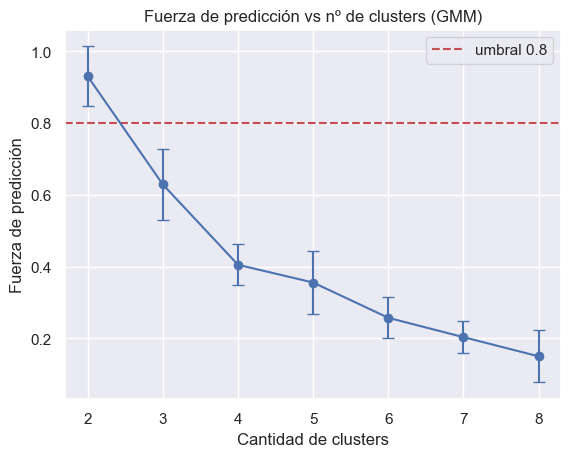

In [14]:
ks_gmm = range(2, 9)
reps = 10
ps_mean = np.zeros(len(ks_gmm))
ps_std = np.zeros(len(ks_gmm))

for idx, k in enumerate(ks_gmm):
    loop = np.zeros(reps)
    for r in range(reps):
        m, _ = prediction_strength_cross_validation(
            X_scaled,
            GaussianMixture(n_components=k, covariance_type='full',
                            random_state=RANDOM_STATE),
            cross_validation_split=5,
            type_model='mixture')
        loop[r] = m
    ps_mean[idx] = loop.mean()
    ps_std[idx] = loop.std()

plt.errorbar(list(ks_gmm), ps_mean, yerr=ps_std, marker='o', capsize=4)
plt.axhline(0.8, color='r', linestyle='--', label='umbral 0.8')
plt.xlabel('Cantidad de clusters'); plt.ylabel('Fuerza de predicción')
plt.title('Fuerza de predicción vs nº de clusters (GMM)')
plt.xticks(list(ks_gmm)); plt.legend(); plt.show()

**2.1 — ¿Qué número de clusters sugiere la fuerza de predicción?**

Si tomamos valores por encima del umbral, 2 grupos es el numero de cluster a considerar. En base a los que vimos anteriormente, tiene sentido porque la especie setosa tiene una clara separacion de las otras dos especies en cuanto a sus distribuciones

### 2.2 – 2.3 Modelo GMM y voto de mayoría

Entrenamos `GaussianMixture` con `k = 3` sobre el 80% y asignamos especie a cada componente por voto de mayoría.

In [15]:
GMM_K = 3
gmm = GaussianMixture(n_components=GMM_K, covariance_type='full',
                      random_state=RANDOM_STATE)
clusters_train_gmm = gmm.fit_predict(X_train)

map_gmm = map_clusters_to_labels(clusters_train_gmm, y_train)
print('Mapeo componente -> especie:',
      {int(c): species_names[lbl] for c, lbl in map_gmm.items()})
pd.crosstab(clusters_train_gmm, pd.Series(y_train, name='especie_real'))

Mapeo componente -> especie: {0: 'Iris-setosa', 1: 'Iris-virginica', 2: 'Iris-versicolor'}


especie_real,0,1,2
row_0,,,
0,40,0,0
1,0,2,39
2,0,38,1


### 2.4 Clasificación del 20% reservado

GMM sí tiene `predict`. Evaluamos igual que antes.

Accuracy (test): 1.0000
ARI (test):      1.0000

                 precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00        10
Iris-versicolor       1.00      1.00      1.00        10
 Iris-virginica       1.00      1.00      1.00        10

       accuracy                           1.00        30
      macro avg       1.00      1.00      1.00        30
   weighted avg       1.00      1.00      1.00        30



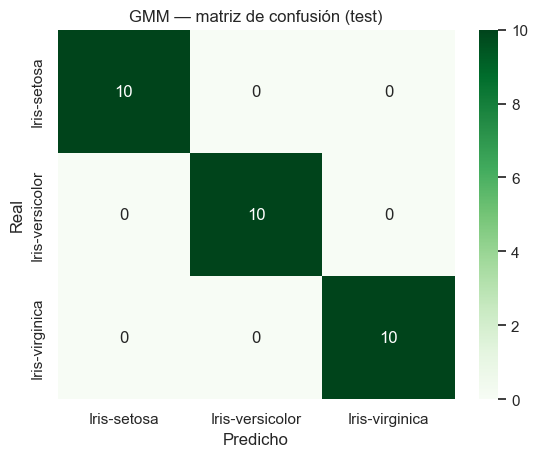

In [16]:
clusters_test_gmm = gmm.predict(X_test)
y_pred_gmm = predict_class(clusters_test_gmm, map_gmm)

acc_gmm = accuracy_score(y_test, y_pred_gmm)
ari_gmm = adjusted_rand_score(y_test, clusters_test_gmm)
print(f'Accuracy (test): {acc_gmm:.4f}')
print(f'ARI (test):      {ari_gmm:.4f}')
print()
print(classification_report(y_test, y_pred_gmm, target_names=species_names))

cm = confusion_matrix(y_test, y_pred_gmm)
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens',
            xticklabels=species_names, yticklabels=species_names)
plt.title('GMM — matriz de confusión (test)')
plt.xlabel('Predicho'); plt.ylabel('Real'); plt.show()

**2.4 — ¿Qué resultado obtuvo? ¿Qué tan correcto fue el agrupamiento?**

El agrupamiento es perfecto, GMM no le erro en ninguno. Tiene sentido porque usamos el metodo de covarianza full, que puede armar distribuciones gaussianas que expliquen muy bien los datos y entrega probabilidades reales que el modelo puede usar correctamente para discriminar los grupos de datos

## Ejercicio 3 — Clustering jerárquico

### 3.1 Dendrograma

Construimos el linkage con el método de **Ward** (distancia euclidiana, igual que la teoría) sobre todos los datos escalados y dibujamos el dendrograma. El `color_threshold` marca el corte para tres grupos.

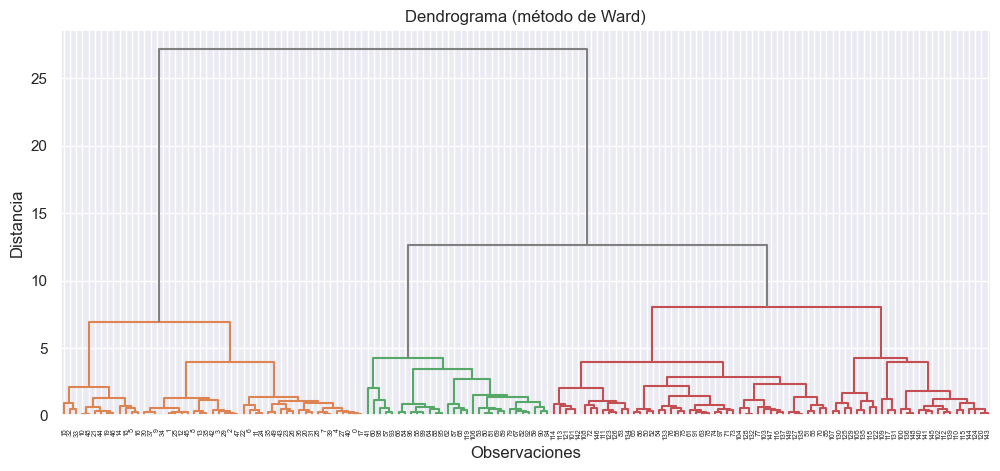

In [17]:
Z = linkage(X_scaled, method='ward')
plt.figure(figsize=(12, 5))
dendrogram(Z, color_threshold=Z[-2, 2], above_threshold_color='gray')
plt.title('Dendrograma (método de Ward)')
plt.xlabel('Observaciones'); plt.ylabel('Distancia')
plt.show()

### 3.2 Número óptimo de clusters

El número de clusters se lee del dendrograma cortando a una altura donde las ramas dan saltos grandes de distancia.

**3.2 — ¿Cuántos clusters sugiere el dendrograma?**

Sugiere 2 o 3, que es donde estan los mayores saltos de distancias

### 3.3 – 3.4 Modelo jerárquico y voto de mayoría

Entrenamos `AgglomerativeClustering` (Ward) con `k = 3` sobre el 80% y asignamos especie a cada cluster por voto de mayoría.

In [18]:
HC_K = 3
hc = AgglomerativeClustering(n_clusters=HC_K, linkage='ward')
clusters_train_hc = hc.fit_predict(X_train)

map_hc = map_clusters_to_labels(clusters_train_hc, y_train)
print('Mapeo cluster -> especie:',
      {int(c): species_names[lbl] for c, lbl in map_hc.items()})
pd.crosstab(clusters_train_hc, pd.Series(y_train, name='especie_real'))

Mapeo cluster -> especie: {0: 'Iris-setosa', 1: 'Iris-versicolor', 2: 'Iris-virginica'}


especie_real,0,1,2
row_0,,,
0,40,0,0
1,0,36,17
2,0,4,23


### 3.5 Clasificación del 20% reservado

`AgglomerativeClustering` **no tiene `predict`** (no genera un modelo paramétrico reutilizable). Para clasificar el test calculamos el centroide de cada cluster en el train y asignamos cada flor de test al **centroide más cercano** (criterio consistente con K-means, lo que permite comparar).

Accuracy (test): 0.8000
ARI (test):      0.5489

                 precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00        10
Iris-versicolor       0.70      0.70      0.70        10
 Iris-virginica       0.70      0.70      0.70        10

       accuracy                           0.80        30
      macro avg       0.80      0.80      0.80        30
   weighted avg       0.80      0.80      0.80        30



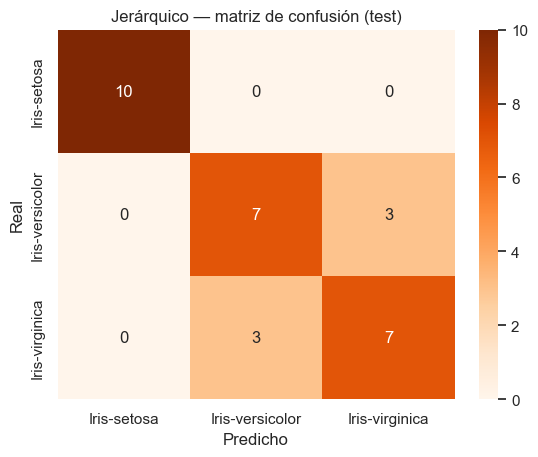

In [19]:
clusters_test_hc = assign_by_nearest_centroid(X_train, clusters_train_hc, X_test)
y_pred_hc = predict_class(clusters_test_hc, map_hc)

acc_hc = accuracy_score(y_test, y_pred_hc)
ari_hc = adjusted_rand_score(y_test, clusters_test_hc)
print(f'Accuracy (test): {acc_hc:.4f}')
print(f'ARI (test):      {ari_hc:.4f}')
print()
print(classification_report(y_test, y_pred_hc, target_names=species_names))

cm = confusion_matrix(y_test, y_pred_hc)
sns.heatmap(cm, annot=True, fmt='d', cmap='Oranges',
            xticklabels=species_names, yticklabels=species_names)
plt.title('Jerárquico — matriz de confusión (test)')
plt.xlabel('Predicho'); plt.ylabel('Real'); plt.show()

**3.5 — ¿Qué resultado obtuvo? ¿Qué tan correcto fue el agrupamiento?**

El error fue igual al K-means

### 3.6 Comparación final: KNN vs K-means vs GMM vs Jerárquico

Reunimos las métricas de los cuatro métodos sobre el **mismo 20% de test**.

In [20]:
comparacion = pd.DataFrame({
    'Modelo': ['KNN (supervisado)', 'K-means', 'GMM', 'Jerárquico (Ward)'],
    'Accuracy': [acc_knn, acc_km, acc_gmm, acc_hc],
    'ARI': [ari_knn, ari_km, ari_gmm, ari_hc],
})
comparacion

,Modelo,Accuracy,ARI
0,KNN (supervisado),0.933333,0.808229
1,K-means,0.800000,0.548889
2,GMM,1.000000,1.000000
3,Jerárquico (Ward),0.800000,0.548889


**3.6 — ¿Cómo fue el rendimiento de los distintos modelos? ¿Cuál agrupó mejor respecto de las especies reales?**

El resultado fue bueno, el modelo que mejorar agrupa con respecto a las especies reales es GMM que logra entender las distribuciones reales de los datos con distribuciones normal ajustadas, lo que lo hace mas robusto. En este caso nosotros tenemos un dataset muy chico por lo que el entrenamiento es muy rapido, pero en dataset grandes si bien el resultado es mejor, puede tardar muchisimo en entrenar y quizas podemos optar por metodos mas simples que entreguen resultados que nos sirvan para nuestro proposito